# Exploratory Data Analysis


Estimated time needed: **30** minutes
    

## Objectives

After completing this lab you will be able to:

* Explore features or characteristics to predict price of car
* Analyze patterns and run descriptive statistical analysis
* Group data based on identified parameters and create pivot tables
* Identify the effect of independent attributes on price of cars


> **How this lab flows (read this first).**
>
> We explore an automobile dataset to discover **which features best predict a car's price**, then finish by producing a **clean, model-ready dataset**. The path is:
>
> 1. Load the data and look at it.
> 2. Visualize how individual features relate to price (scatter plots, boxplots).
> 3. Use descriptive statistics and grouping to dig deeper.
> 4. Measure relationships numerically with correlation and the Pearson test.
> 5. **Select the important features** (the original lab stops here).
> 6. **Clean the data** — handle duplicates, missing values and outliers — and save a final dataset ready for a model *(added section)*.
>
> The dataset file `automobileEDA.csv` must be in the **same folder** as this notebook. If a cell reports *FileNotFoundError*, that is why.


<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href='#Import-Data'>Import Data</a>
    <li><a href='#Analyzing-Individual-Feature-Patterns-Using-Visualization'>Analyzing Individual Feature Patterns using Visualization</a>
    <li><a href='#Descriptive-Statistical-Analysis'>Descriptive Statistical Analysis</a>
    <li><a href='#Basics-of-Grouping'>Basics of Grouping</a>
    <li><a href='#Correlation-and-Causation'>Correlation and Causation</a>
</ol>

</div>
 
<hr>


<h3>What are the main characteristics that have the most impact on the car price?</h3>


<h4>Setup</h4>


Import libraries: 


In [1]:
import pandas as pd
import numpy as np

In [ ]:
file_path = r"D:\AI\Huawei_HCCDA_AI_Course\week_04\sunday\datasets\automobileEDA.csv"   # the CSV sits in the same folder as this notebook

In [3]:
df = pd.read_csv(file_path, header=0)

View the first 5 values of the updated dataframe using `dataframe.head()`


In [4]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


**A quick sanity check before we analyse.** Real files sometimes contain impossible placeholder values (like a price of `99999` meaning "unknown"). Left in, they distort every statistic. We remove that one obvious error now so the analysis below is trustworthy; the full cleaning of duplicates and missing values comes in Part 2 at the end.


In [5]:
print("rows loaded:", len(df))
print("impossible price placeholders (99999):", (df["price"] == 99999).sum())
df = df[df["price"] != 99999].reset_index(drop=True)
print("rows after removing them:", len(df))

rows loaded: 201
impossible price placeholders (99999): 0
rows after removing them: 201


## Analyzing Individual Feature Patterns Using Visualization


To install Seaborn we use pip, the Python package manager.


Import visualization packages "Matplotlib" and "Seaborn". 


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns 

<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>


In [7]:
# list the data types for each column
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #1:</h3>

<b>What is the data type of the column "peak-rpm"? </b>
</div>


In [8]:
# Question 1: what is the data type of the "peak-rpm" column?
df["peak-rpm"].dtypes

dtype('float64')

<details><summary>Click here for the solution</summary>

```python    
df['peak-rpm'].dtypes
```

</details>


For example, we can calculate the correlation between variables  of type "int64" or "float64" using the method "corr":


In [10]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print(numeric_df.shape)
numeric_df.corr()

(201, 19)


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


<Axes: >

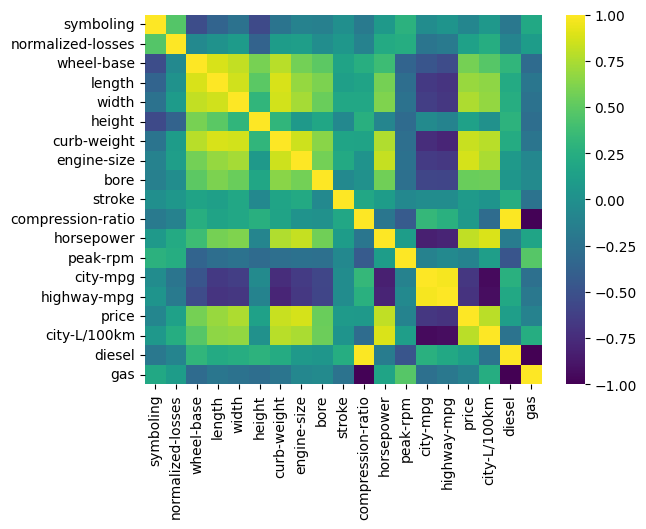

In [14]:
sns.heatmap(data=numeric_df.corr(), vmin=-1, vmax=1, cmap='viridis')

The diagonal elements are always one; we will study correlation more precisely Pearson correlation in-depth at the end of the notebook.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3> Question  #2: </h3>

<p>Find the correlation between the following columns: bore, stroke, compression-ratio, and horsepower.</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[['bore','stroke','compression-ratio','horsepower']]</p>
</div>


In [15]:
# Question 2: correlation between bore, stroke, compression-ratio and horsepower
df[["bore", "stroke", "compression-ratio", "horsepower"]].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


<details><summary>Click here for the solution</summary>

```python
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()
```

</details>


<h2>Continuous Numerical Variables:</h2> 

<p>Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots with fitted lines.</p>

<p>In order to start understanding the (linear) relationship between an individual variable and the price, we can use "regplot" which plots the scatterplot plus the fitted regression line for the data. This will be useful later on for visualizing the fit of the simple linear regression model as well. </p>


 Let's see several examples of different linear relationships:


<h3>Positive Linear Relationship</h4>


Let's find the scatterplot of "engine-size" and "price".


(0.0, 53439.78629978341)

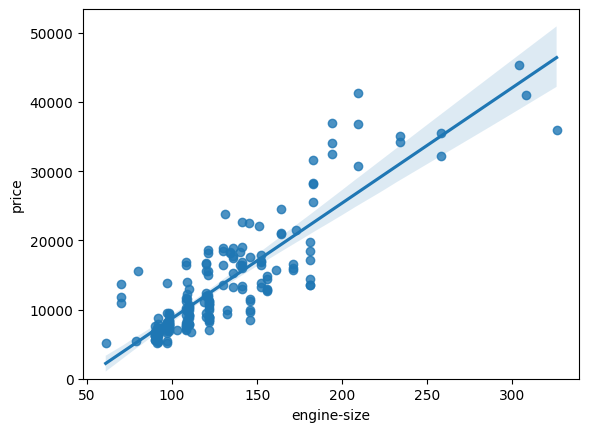

In [16]:
# Engine size as potential predictor variable of price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

<p>As the engine-size goes up, the price goes up: this indicates a positive direct correlation between these two variables. Engine size seems like a pretty good predictor of price since the regression line is almost a perfect diagonal line.</p>


We can examine the correlation between 'engine-size' and 'price'. It is strongly positive (around 0.9 in this dataset), which is why engine size is one of the best predictors of price.


In [17]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


Highway mpg is a potential predictor variable of price. Let's find the scatterplot of "highway-mpg" and "price".


<Axes: xlabel='highway-mpg', ylabel='price'>

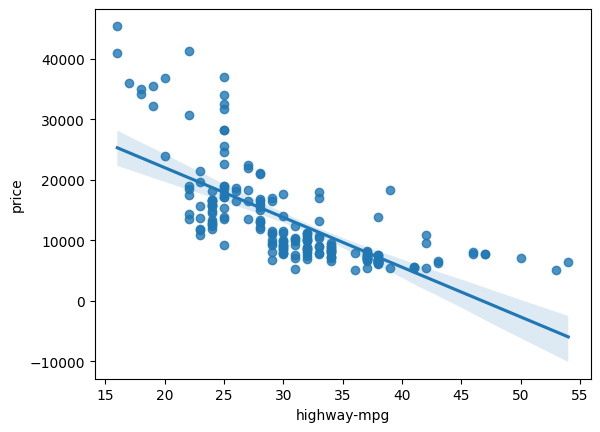

In [19]:
sns.regplot(x="highway-mpg", y="price", data=df)

<p>As highway-mpg goes up, the price goes down: this indicates an inverse/negative relationship between these two variables. Highway mpg could potentially be a predictor of price.</p>


We can examine the correlation between 'highway-mpg' and 'price'. It is strongly negative here — as fuel economy rises, price tends to fall.


In [20]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


<h3>Weak Linear Relationship</h3>


Let's see if "peak-rpm" is a predictor variable of "price".


<Axes: xlabel='peak-rpm', ylabel='price'>

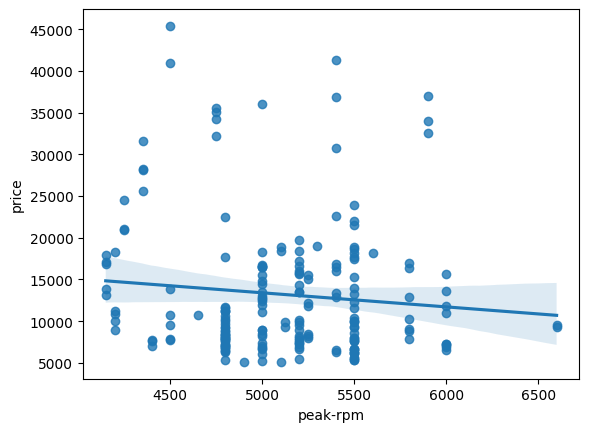

In [21]:
sns.regplot(x="peak-rpm", y="price", data=df)

<p>Peak rpm does not seem like a good predictor of the price at all since the regression line is close to horizontal. Also, the data points are very scattered and far from the fitted line, showing lots of variability. Therefore, it's not a reliable variable.</p>


We can examine the correlation between 'peak-rpm' and 'price' and see it's approximately -0.101616.


In [22]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


 <div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  3 a): </h1>

<p>Find the correlation  between x="stroke" and y="price".</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[["stroke","price"]].  </p>
</div>


In [23]:
# Find the correlation between "stroke" and "price"
df[["stroke", "price"]].corr()

,stroke,price
stroke,1.00000,0.08231
price,0.08231,1.00000


<details><summary>Click here for the solution</summary>

```python

#The correlation is 0.0823, the non-diagonal elements of the table.

df[["stroke","price"]].corr()

```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question  3 b):</h1>

<p>Given the correlation results between "price" and "stroke", do you expect a linear relationship?</p> 
<p>Verify your results using the function "regplot()".</p>
</div>


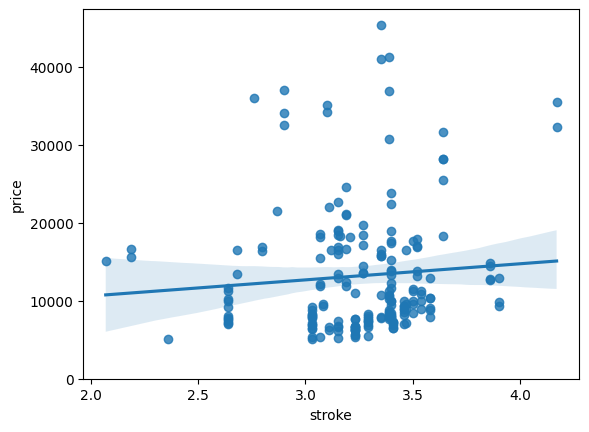

In [24]:
# Visualize the (weak) relationship between stroke and price
sns.regplot(x="stroke", y="price", data=df)
plt.ylim(0,)
plt.show()

<details><summary>Click here for the solution</summary>

```python

#There is a weak correlation between the variable 'stroke' and 'price.' as such regression will not work well. We can see this using "regplot" to demonstrate this.

#Code: 
sns.regplot(x="stroke", y="price", data=df)

```

</details>


<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.</p>


Let's look at the relationship between "body-style" and "price".


<Axes: xlabel='body-style', ylabel='price'>

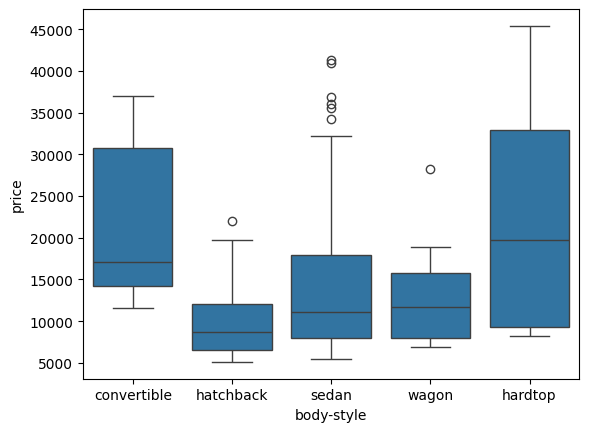

In [25]:
sns.boxplot(x="body-style", y="price", data=df)

<p>We see that the distributions of price between the different body-style categories have a significant overlap, so body-style would not be a good predictor of price. Let's examine engine "engine-location" and "price":</p>


<Axes: xlabel='engine-location', ylabel='price'>

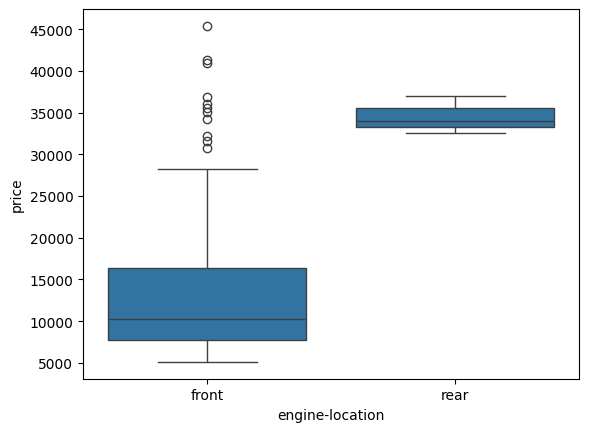

In [26]:
sns.boxplot(x="engine-location", y="price", data=df)

<p>Here we see that the distribution of price between these two engine-location categories, front and rear, are distinct enough to take engine-location as a potential good predictor of price.</p>


 Let's examine "drive-wheels" and "price".


<Axes: xlabel='drive-wheels', ylabel='price'>

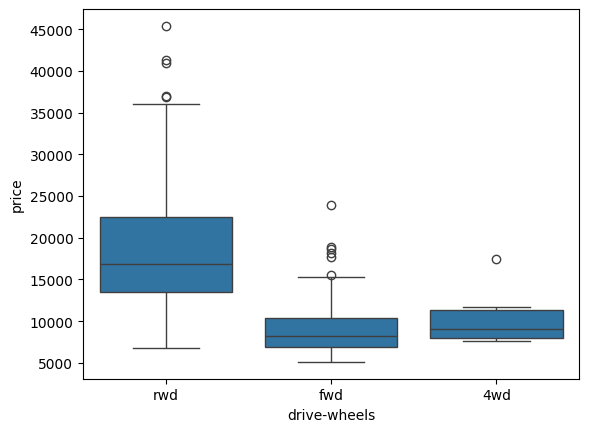

In [27]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>Here we see that the distribution of price between the different drive-wheels categories differs. As such, drive-wheels could potentially be a predictor of price.</p>


## Descriptive Statistical Analysis


<p>Let's first take a look at the variables by utilizing a description method.</p>

<p>The <b>describe</b> function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.</p>

This will show:
<ul>
    <li>the count of that variable</li>
    <li>the mean</li>
    <li>the standard deviation (std)</li> 
    <li>the minimum value</li>
    <li>the IQR (Interquartile Range: 25%, 50% and 75%)</li>
    <li>the maximum value</li>
<ul>


 We can apply the method "describe" as follows:


In [28]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


 The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:


In [29]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


<h3>Value Counts</h3>


<p>Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "drive-wheels". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket <code>df['drive-wheels']</code>, not two brackets <code>df[['drive-wheels']]</code>.</p>


In [30]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the series to a dataframe as follows:


In [31]:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


Let's repeat the above steps but save the results to the dataframe "drive_wheels_counts" and rename the column  'drive-wheels' to 'value_counts'.


In [40]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts=drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'})
drive_wheels_counts

,value_counts,count
0,fwd,118
1,rwd,75
2,4wd,8


 Now let's rename the index to 'drive-wheels':


In [41]:
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


We can repeat the above process for the variable 'engine-location'.


In [42]:
# engine-location as variable
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


<p>After examining the value counts of the engine location, we see that engine location would not be a good predictor variable for the price. This is because we only have three cars with a rear engine and 198 with an engine in the front, so this result is skewed. Thus, we are not able to draw any conclusions about the engine location.</p>


## Basics of Grouping


<p>The "groupby" method groups data by different categories. The data is grouped based on one or several variables, and analysis is performed on the individual groups.</p>

<p>For example, let's group by the variable "drive-wheels". We see that there are 3 different categories of drive wheels.</p>


In [43]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

<p>If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.</p>

<p>We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".</p>


In [45]:
df_group_one = df[['drive-wheels','body-style','price']]
df_group_one

,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0
...,...,...,...
196,rwd,sedan,16845.0
197,rwd,sedan,19045.0
198,rwd,sedan,21485.0
199,rwd,sedan,22470.0


We can then calculate the average price for each of the different categories of data.


In [47]:
# grouping results
df_grouped = df_group_one.groupby(['drive-wheels'], as_index=False).agg({'price': 'mean'})
df_grouped

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


<p>From our data, it seems rear-wheel drive vehicles are, on average, the most expensive, while 4-wheel and front-wheel are approximately the same in price.</p>

<p>You can also group by multiple variables. For example, let's group by both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'. We can store the results in the variable 'grouped_test1'.</p>


In [48]:
# grouping results
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


<p>This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.</p>

<p>In this case, we will leave the drive-wheels variable as the rows of the table, and pivot body-style to become the columns of the table:</p>


In [49]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p>Often, we won't have data for some of the pivot cells. We can fill these missing cells with the value 0, but any other value could potentially be used as well. It should be mentioned that missing data is quite a complex subject and is an entire course on its own.</p>


In [50]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 4:</h1>

<p>Use the "groupby" function to find the average "price" of each car based on "body-style".</p>
</div>


In [51]:
# Group the "body-style" column by average price
df_gptest2 = df[["body-style", "price"]]
grouped_bodystyle = df_gptest2.groupby(["body-style"], as_index=False)["price"].mean()
grouped_bodystyle

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


<details><summary>Click here for the solution</summary>

```python
# grouping results
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'],as_index= False).mean()
grouped_test_bodystyle

```

</details>


If you did not import "pyplot", let's do it again. 


In [38]:
import matplotlib.pyplot as plt
%matplotlib inline 

<h4>Variables: Drive Wheels and Body Style vs. Price</h4>


Let's use a heat map to visualize the relationship between Body Style vs Price.


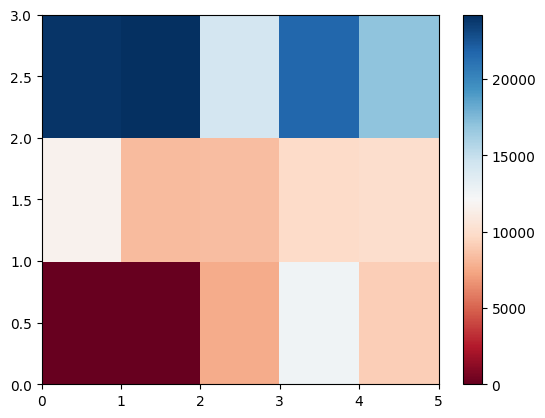

In [52]:
#use the grouped results
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

<p>The heatmap plots the target variable (price) proportional to colour with respect to the variables 'drive-wheel' and 'body-style' on the vertical and horizontal axis, respectively. This allows us to visualize how the price is related to 'drive-wheel' and 'body-style'.</p>

<p>The default labels convey no useful information to us. Let's change that:</p>


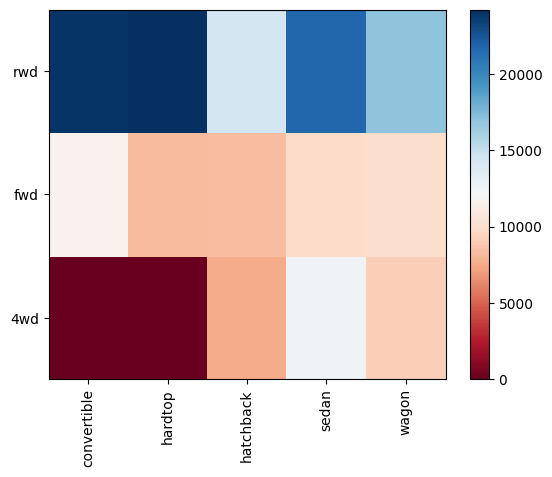

In [53]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

<p>Visualization is very important in data science, and Python visualization packages provide great freedom. We will go more in-depth in a separate Python visualizations course.</p>

<p>The main question we want to answer in this module is, "What are the main characteristics which have the most impact on the car price?".</p>

<p>To get a better measure of the important characteristics, we look at the correlation of these variables with the car price. In other words: how is the car price dependent on this variable?</p>


## Correlation and Causation


<p><b>Correlation</b>: a measure of the extent of interdependence between variables.</p>

<p><b>Causation</b>: the relationship between cause and effect between two variables.</p>

<p>It is important to know the difference between these two. Correlation does not imply causation. Determining correlation is much simpler  the determining causation as causation may require independent experimentation.</p>


<p><b>Pearson Correlation</b></p>
<p>The Pearson Correlation measures the linear dependence between two variables X and Y.</p>
<p>The resulting coefficient is a value between -1 and 1 inclusive, where:</p>
<ul>
    <li><b>1</b>: Perfect positive linear correlation.</li>
    <li><b>0</b>: No linear correlation, the two variables most likely do not affect each other.</li>
    <li><b>-1</b>: Perfect negative linear correlation.</li>
</ul>


<p>Pearson Correlation is the default method of the function "corr". Like before, we can calculate the Pearson Correlation of the of the 'int64' or 'float64'  variables.</p>


In [54]:
df.select_dtypes(include=['number']).corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


Sometimes we would like to know the significant of the correlation estimate. 


<b>P-value</b>
<p>What is this P-value? The P-value is the probability value that the correlation between these two variables is statistically significant. Normally, we choose a significance level of 0.05, which means that we are 95% confident that the correlation between the variables is significant.</p>

By convention, when the
<ul>
    <li>p-value is $<$ 0.001: we say there is strong evidence that the correlation is significant.</li>
    <li>the p-value is $<$ 0.05: there is moderate evidence that the correlation is significant.</li>
    <li>the p-value is $<$ 0.1: there is weak evidence that the correlation is significant.</li>
    <li>the p-value is $>$ 0.1: there is no evidence that the correlation is significant.</li>
</ul>


 We can obtain this information using  "stats" module in the "scipy"  library.


In [55]:
from scipy import stats

<h3>Wheel-Base vs. Price</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'wheel-base' and 'price'. 


In [56]:
# drop rows where either column is missing, then run the test
_pair = df[['wheel-base', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['wheel-base'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.585  | P-value: 8.076488270732847e-20


**Conclusion:** the p-value is well below 0.001, so the correlation between wheel-base and price is statistically significant. The coefficient printed above shows the relationship is positive and moderate.


<h3>Horsepower vs. Price</h3>


 Let's calculate the  Pearson Correlation Coefficient and P-value of 'horsepower' and 'price'.


In [57]:
# drop rows where either column is missing, then run the test
_pair = df[['horsepower', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['horsepower'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.81  | P-value: 6.369057428259638e-48


**Conclusion:** the p-value is below 0.001, so the horsepower–price correlation is statistically significant, and the coefficient printed above shows it is strong and positive.


<h3>Length vs. Price</h3>

Let's calculate the  Pearson Correlation Coefficient and P-value of 'length' and 'price'.


In [58]:
# drop rows where either column is missing, then run the test
_pair = df[['length', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['length'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.691  | P-value: 8.016477466159293e-30


**Conclusion:** the p-value is below 0.001, so the length–price correlation is statistically significant, with a moderately strong positive coefficient (see the value printed above).


<h3>Width vs. Price</h3>


 Let's calculate the Pearson Correlation Coefficient and P-value of 'width' and 'price':


In [59]:
# drop rows where either column is missing, then run the test
_pair = df[['width', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['width'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.751  | P-value: 9.200335510480586e-38


**Conclusion:** the p-value is below 0.001, so the width–price correlation is statistically significant and positive (see the coefficient printed above).


### Curb-Weight vs. Price


 Let's calculate the Pearson Correlation Coefficient and P-value of 'curb-weight' and 'price':


In [60]:
# drop rows where either column is missing, then run the test
_pair = df[['curb-weight', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['curb-weight'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.834  | P-value: 2.189577238893924e-53


**Conclusion:** the p-value is below 0.001, so the curb-weight–price correlation is statistically significant and strongly positive (see the value above).


<h3>Engine-Size vs. Price</h3>

Let's calculate the Pearson Correlation Coefficient and P-value of 'engine-size' and 'price':


In [61]:
# drop rows where either column is missing, then run the test
_pair = df[['engine-size', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['engine-size'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.872  | P-value: 9.26549162219869e-64


**Conclusion:** the p-value is below 0.001, so the engine-size–price correlation is statistically significant and very strongly positive — the highest of all the features.


<h3>Bore vs. Price</h3>


 Let's calculate the  Pearson Correlation Coefficient and P-value of 'bore' and 'price':


In [62]:
# drop rows where either column is missing, then run the test
_pair = df[['bore', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['bore'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: 0.543  | P-value: 8.049189483935274e-17


**Conclusion:** the p-value is below 0.001, so the bore–price correlation is statistically significant, with a moderate positive coefficient (see above).


 We can relate the process for each 'city-mpg'  and 'highway-mpg':


<h3>City-mpg vs. Price</h3>


In [63]:
# drop rows where either column is missing, then run the test
_pair = df[['city-mpg', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['city-mpg'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: -0.687  | P-value: 2.3211320655675065e-29


**Conclusion:** the p-value is below 0.001, so the city-mpg–price correlation is statistically significant and negative (see the coefficient above).


<h3>Highway-mpg vs. Price</h3>


In [64]:
# drop rows where either column is missing, then run the test
_pair = df[['highway-mpg', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(_pair['highway-mpg'], _pair['price'])
print("Pearson coefficient:", round(pearson_coef, 3), " | P-value:", p_value)

Pearson coefficient: -0.705  | P-value: 1.749547114447559e-31


**Conclusion:** the p-value is below 0.001, so the highway-mpg–price correlation is statistically significant and negative (see the coefficient above).


<h3>Conclusion: Important Variables</h3>


<p>We now have a better idea of what our data looks like and which variables are important to take into account when predicting the car price. We have narrowed it down to the following variables:</p>

Continuous numerical variables:
<ul>
    <li>Length</li>
    <li>Width</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Horsepower</li>
    <li>City-mpg</li>
    <li>Highway-mpg</li>
    <li>Wheel-base</li>
    <li>Bore</li>
</ul>
    
Categorical variables:
<ul>
    <li>Drive-wheels</li>
</ul>

<p>As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.</p>


---
# Part 2 — From Analysis to a Clean, Model-Ready Dataset

The analysis above told us **which features matter**. But we cannot train a model on the data as it stands — real data is messy, and a model will either crash on it or learn from bad values. This final part turns the explored data into a clean table ready for machine learning.

We caught the one impossible value (the `99999` price) at the very start, so the analysis would be trustworthy. Now we finish the job for modelling by fixing what remains, in a deliberate order:
1. **Duplicate rows** — the same car listed twice biases every statistic.
2. **Missing values** — gaps a model cannot read.
3. **Feature selection** — keep only the columns worth modelling on.
4. **Encoding** — turn text categories into numbers.

Order matters: remove duplicates first (so we don't fill them), then fill the genuine gaps, then select and encode.

## Step 1 — Inspect the mess

First, measure the problems honestly before fixing anything.

In [65]:
print("rows:", len(df))
print("duplicate rows:", df.duplicated().sum())
print()
print("missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

rows: 201
duplicate rows: 0

missing values per column:
stroke               4
horsepower-binned    1
dtype: int64


In [66]:
# The price column is already free of the 99999 placeholder (removed at the start).
# Confirm its range now looks like real car prices:
df["price"].describe()

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64

The maximum price is now a realistic figure — the impossible `99999` was already removed at the start of the lab, which is why the correlations in the analysis came out sensibly. What remains to fix is duplicates and genuine missing values.

## Step 2 — Remove duplicate rows

A duplicate is the exact same record entered twice. It silently double-counts a car in every average and correlation.

In [67]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"removed {before - len(df)} duplicate rows; {len(df)} remain")

removed 0 duplicate rows; 201 remain


## Step 3 — Handle missing values

Two rules of thumb:
- **Numeric columns** → fill with the **median** (safe against skew, unlike the mean).
- **Categorical columns** → fill with the **mode** (the most common category).

But there is one exception: if the value we are trying to *predict* (`price`) is missing, we cannot use that row to train — there's no answer to learn from. Those rows are dropped, not filled.

In [68]:
# 3a. Drop rows where the TARGET (price) is missing — we can't learn from them
before = len(df)
df = df.dropna(subset=["price"]).reset_index(drop=True)
print(f"dropped {before - len(df)} rows with no price; {len(df)} remain")

dropped 0 rows with no price; 201 remain


In [69]:
# 3b. Fill missing NUMERIC values with each column's median
numeric_cols = df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        median = df[col].median()
        df[col] = df[col].fillna(median)
        print(f"filled {col:20s} with median {median}")

filled stroke               with median 3.29


In [70]:
# 3c. Fill missing CATEGORICAL values with the mode (most common value)
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    if df[col].isnull().any():
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)
        print(f"filled {col:20s} with mode '{mode}'")

filled horsepower-binned    with mode 'Low'


In [71]:
# Confirm the data is now complete
print("total missing values remaining:", df.isnull().sum().sum())

total missing values remaining: 0


## Step 4 — Select the features for the model

From the correlation analysis above, these columns have the strongest relationship with price. We keep them plus `price` itself (the target), and drop the weakly-related columns that would add noise more than signal.

*(This is the list the original lab concluded with — now we actually build the dataset from it.)*

In [72]:
# The strong predictors identified during the analysis
selected_features = [
    "length", "width", "curb-weight", "engine-size",
    "horsepower", "wheel-base", "bore", "city-mpg", "highway-mpg",
    "drive-wheels",          # a categorical feature that showed clear price differences
    "price"                  # the target we want to predict
]

model_df = df[selected_features].copy()
model_df.head()

,length,width,curb-weight,engine-size,horsepower,wheel-base,bore,city-mpg,highway-mpg,drive-wheels,price
0,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,rwd,13495.0
1,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,rwd,16500.0
2,0.822681,0.909722,2823,152,154.0,94.5,2.68,19,26,rwd,16500.0
3,0.848630,0.919444,2337,109,102.0,99.8,3.19,24,30,fwd,13950.0
4,0.848630,0.922222,2824,136,115.0,99.4,3.19,18,22,4wd,17450.0


## Step 5 — Encode the categorical feature

Models work with numbers, not text. `drive-wheels` is text (`fwd`, `rwd`, `4wd`), so we convert it into numeric columns with **one-hot encoding** (`pd.get_dummies`): one 0/1 column per category. This is the last step that stands between us and a fully numeric table.

In [73]:
model_df = pd.get_dummies(model_df, columns=["drive-wheels"], drop_first=True)
model_df.head()

,length,width,curb-weight,engine-size,horsepower,wheel-base,bore,city-mpg,highway-mpg,price,drive-wheels_fwd,drive-wheels_rwd
0,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,13495.0,False,True
1,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,16500.0,False,True
2,0.822681,0.909722,2823,152,154.0,94.5,2.68,19,26,16500.0,False,True
3,0.848630,0.919444,2337,109,102.0,99.8,3.19,24,30,13950.0,True,False
4,0.848630,0.922222,2824,136,115.0,99.4,3.19,18,22,17450.0,False,False


Each `drive-wheels_*` column is now a 0/1 flag. `drop_first=True` removes one redundant column (if a car is neither `fwd` nor `rwd`, it must be `4wd`), which is standard practice.

## Step 6 — The final, model-ready dataset

Every column is numeric, there are no missing values, no duplicates, and no impossible entries. This is exactly the kind of table a machine-learning model expects.

In [74]:
print("final shape:", model_df.shape)
print("any missing values?", model_df.isnull().sum().sum())
print("all numeric?", (model_df.dtypes != "object").all())
model_df.head()

final shape: (201, 12)
any missing values? 0
all numeric? True


,length,width,curb-weight,engine-size,horsepower,wheel-base,bore,city-mpg,highway-mpg,price,drive-wheels_fwd,drive-wheels_rwd
0,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,13495.0,False,True
1,0.811148,0.890278,2548,130,111.0,88.6,3.47,21,27,16500.0,False,True
2,0.822681,0.909722,2823,152,154.0,94.5,2.68,19,26,16500.0,False,True
3,0.848630,0.919444,2337,109,102.0,99.8,3.19,24,30,13950.0,True,False
4,0.848630,0.922222,2824,136,115.0,99.4,3.19,18,22,17450.0,False,False


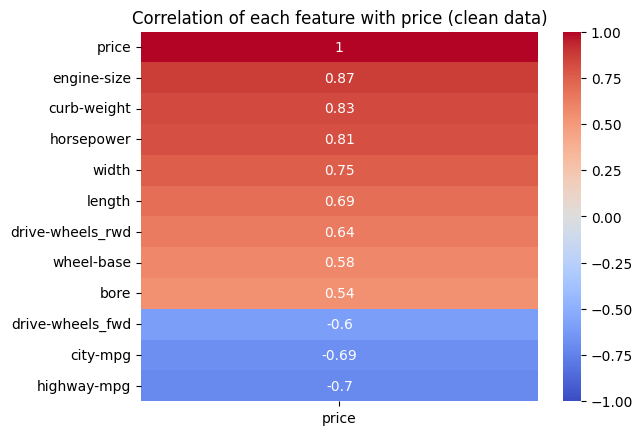

In [75]:
# One last look: does the cleaned data still show the relationships we found?
import seaborn as sns
sns.heatmap(model_df.corr()[["price"]].sort_values("price", ascending=False),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of each feature with price (clean data)")
plt.show()

In [76]:
# Save the clean dataset so it can be loaded directly for modelling next week
model_df.to_csv("automobile_clean.csv", index=False)
print("saved automobile_clean.csv —", model_df.shape[0], "rows,", model_df.shape[1], "columns")

saved automobile_clean.csv — 201 rows, 12 columns


---
## Summary — what we did

**Analysis (Part 1):** explored the automobile data with scatter plots, boxplots, grouping and correlation to discover which features best predict price. Engine size, curb weight, horsepower and the car's dimensions came out strongest; fuel economy (mpg) related negatively.

**Cleaning (Part 2):** turned the explored data into something a model can actually use —
- removed duplicate rows,
- replaced the impossible `99999` price with missing,
- dropped rows with no price (nothing to learn from),
- filled numeric gaps with the median and categorical gaps with the mode,
- selected the strong features and one-hot encoded the categorical one,
- saved a fully numeric, complete `automobile_clean.csv`.

**The lesson:** exploratory analysis and cleaning are two halves of the same job. The analysis tells you *what* to keep; the cleaning makes it *usable*. Next week, this clean dataset is what we feed to our first predictive model.

---

<div style="background:#0d1117;border:1px solid #21262d;border-radius:16px;padding:28px 30px;font-family:'Segoe UI',system-ui,sans-serif;box-shadow:0 6px 20px rgba(0,0,0,0.4);margin-top:15px;">
  <div style="display:flex;align-items:center;border-bottom:1px solid #21262d;padding-bottom:16px;margin-bottom:16px;">
    <img src="https://github.com/M-Abbas1.png" alt="profile"
         style="width:56px;height:56px;border-radius:50%;margin-right:16px;flex-shrink:0;border:2px solid #00c6a2;object-fit:cover;" />
    <div>
      <div style="color:#ffffff;font-size:20px;font-weight:700;">Muhammad Abbas</div>
      <div style="color:#00c6a2;font-size:14px;font-weight:500;">AI / Machine Learning Instructor</div>
    </div>
  </div>
  <div style="color:#8b949e;font-size:14px;line-height:1.9;">
    <div><span style="color:#00c6a2;">&#127891;</span>&nbsp; <b style="color:#c9d1d9;">Course:</b> Artificial Intelligence (Machine Learning &amp; Deep Learning)</div>
    <div><span style="color:#00c6a2;">&#127970;</span>&nbsp; <b style="color:#c9d1d9;">Program:</b> NAVTTC &mdash; Prime Minister&rsquo;s Hunarmand Pakistan &ldquo;Skills for All&rdquo;</div>
    <div style="margin-top:10px;display:flex;align-items:center;flex-wrap:wrap;gap:6px;">
      <img src="https://cdn.simpleicons.org/gmail/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="mailto:mr.mabbas2@gmail.com" style="color:#58a6ff;text-decoration:none;">mr.mabbas2@gmail.com</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      
      <a href="https://www.linkedin.com/in/muhammad-abbas-b93524279/" style="color:#58a6ff;text-decoration:none;">LinkedIn</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      <img src="https://cdn.simpleicons.org/github/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="https://github.com/M-Abbas1" style="color:#58a6ff;text-decoration:none;">GitHub</a>
    </div>
  </div>
  <div style="border-top:1px solid #21262d;margin-top:16px;padding-top:14px;text-align:center;">
    <span style="color:#6e7681;font-size:13px;font-style:italic;">
      &ldquo;The best way to predict the future is to create it.&rdquo;
    </span>
  </div>
  <div style="text-align:center;margin-top:10px;">
    <span style="color:#484f58;font-size:12px;">&copy; 2026 Muhammad Abbas &nbsp;&bull;&nbsp; Made with &#10084;&#65039; for learning</span>
  </div>
</div>